In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Q1 - Outlier Detection using the Percentile Method

In [87]:
# Generated skewed data

np.random.seed(9009)
data = np.random.exponential(100000,1000)
df = pd.DataFrame({
    'Salary': data,
})
df.head()

,Salary
0,270853.225173
1,8220.783507
2,152398.096813
3,161815.368605
4,4981.101376


In [88]:
# Added 5 extreme values

df.loc[np.random.choice(df.index, 5),'Salary'] = [10000000, 50000000, 190000000, 76000000, 20030000]

In [89]:
# Percentiles

lower = df['Salary'].quantile(0.01)
upper = df['Salary'].quantile(0.99)

print(f'Normal Range: {lower} to {upper}')

Normal Range: 980.6702926356444 to 546360.1615015764


In [90]:
# Remove values

mask = ((df['Salary'] < lower) | (df['Salary'] > upper))
df_clean = df[~mask].copy()
df_clean

,Salary
0,270853.225173
1,8220.783507
2,152398.096813
3,161815.368605
4,4981.101376
...,...
995,25188.710590
996,73285.668140
997,100641.516261
998,546205.879475


In [91]:
df

,Salary
0,270853.225173
1,8220.783507
2,152398.096813
3,161815.368605
4,4981.101376
...,...
995,25188.710590
996,73285.668140
997,100641.516261
998,546205.879475


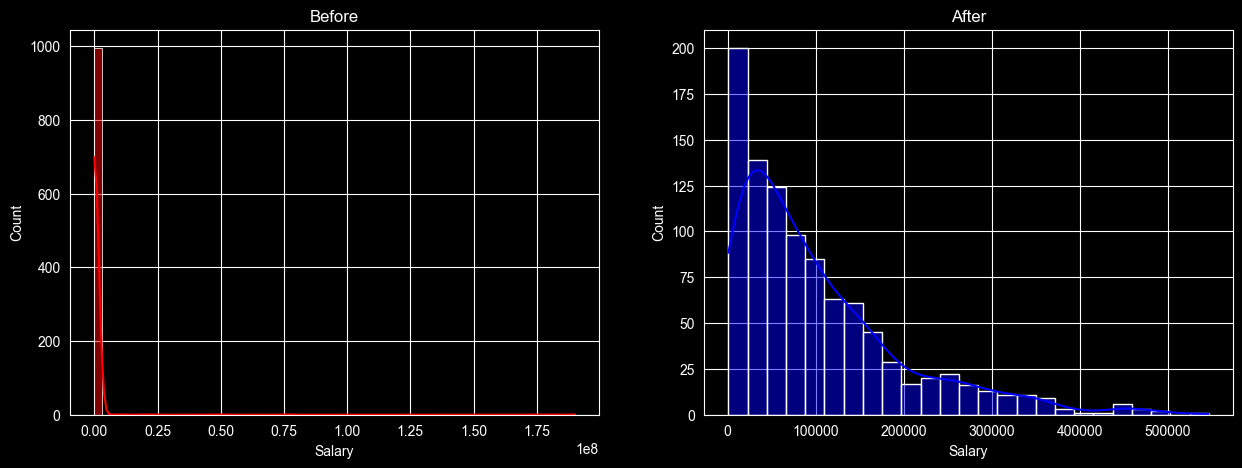

In [92]:
# Before vs After

fig, axes = plt.subplots(1,2,figsize=(15,5))

sns.histplot(data=df , x='Salary', ax=axes[0], color='red',kde=True)
axes[0].set_title('Before')
# axes[0].set_xlim(0,600000)

sns.histplot(data=df_clean , x='Salary', ax=axes[1], color='blue', kde=True)
axes[1].set_title('After')

plt.show()

#### Q2 - Percentile Method with Different Thresholds

In [93]:
# 1 - 99

lower = df['Salary'].quantile(0.01)
upper = df['Salary'].quantile(0.99)


mask = ((df['Salary'] < lower) | (df['Salary'] > upper))
df_clean_1_99 = df[~mask].copy()

print('----1th to 99th----')
display(df_clean_1_99.head())

print(f'Normal Range: {lower:.2f} to {upper:.2f}')
print(f'Dataset Size: {len(df_clean_1_99)}')
print(f'Dataset Mean: {np.mean(df_clean_1_99):.2f}')
print(f'Dataset Std: {np.std(df_clean_1_99):.2f}')

----1th to 99th----


,Salary
0,270853.225173
1,8220.783507
2,152398.096813
3,161815.368605
4,4981.101376


Normal Range: 980.67 to 546360.16
Dataset Size: 980
Dataset Mean: 101080.49
Dataset Std: 95395.88


In [94]:
# 5 - 95

lower = df['Salary'].quantile(0.05)
upper = df['Salary'].quantile(0.95)


mask = ((df['Salary'] < lower) | (df['Salary'] > upper))
df_clean_5_95 = df[~mask].copy()

print('----5th to 95th----')
display(df_clean_5_95.head())

print(f'Normal Range: {lower:.2f} to {upper:.2f}')
print(f'Dataset Size: {len(df_clean_5_95)}')
print(f'Dataset Mean: {np.mean(df_clean_5_95):.2f}')
print(f'Dataset Std: {np.std(df_clean_5_95):.2f}')

----5th to 95th----


,Salary
0,270853.225173
1,8220.783507
2,152398.096813
3,161815.368605
5,127544.140588


Normal Range: 5361.90 to 323420.06
Dataset Size: 900
Dataset Mean: 92642.82
Dataset Std: 74653.08


In [95]:
# 10 - 90

lower = df['Salary'].quantile(0.10)
upper = df['Salary'].quantile(0.90)


mask = ((df['Salary'] < lower) | (df['Salary'] > upper))
df_clean_10_90 = df[~mask].copy()

print('----10th to 90th----')
display(df_clean_10_90.head())

print(f'Normal Range: {lower:.2f} to {upper:.2f}')
print(f'Dataset Size: {len(df_clean_10_90)}')
print(f'Dataset Mean: {np.mean(df_clean_10_90):.2f}')
print(f'Dataset Std: {np.std(df_clean_10_90):.2f}')

----10th to 90th----


,Salary
2,152398.096813
3,161815.368605
5,127544.140588
6,160979.654335
7,99428.383254


Normal Range: 9960.52 to 249250.59
Dataset Size: 800
Dataset Mean: 86168.29
Dataset Std: 59425.64


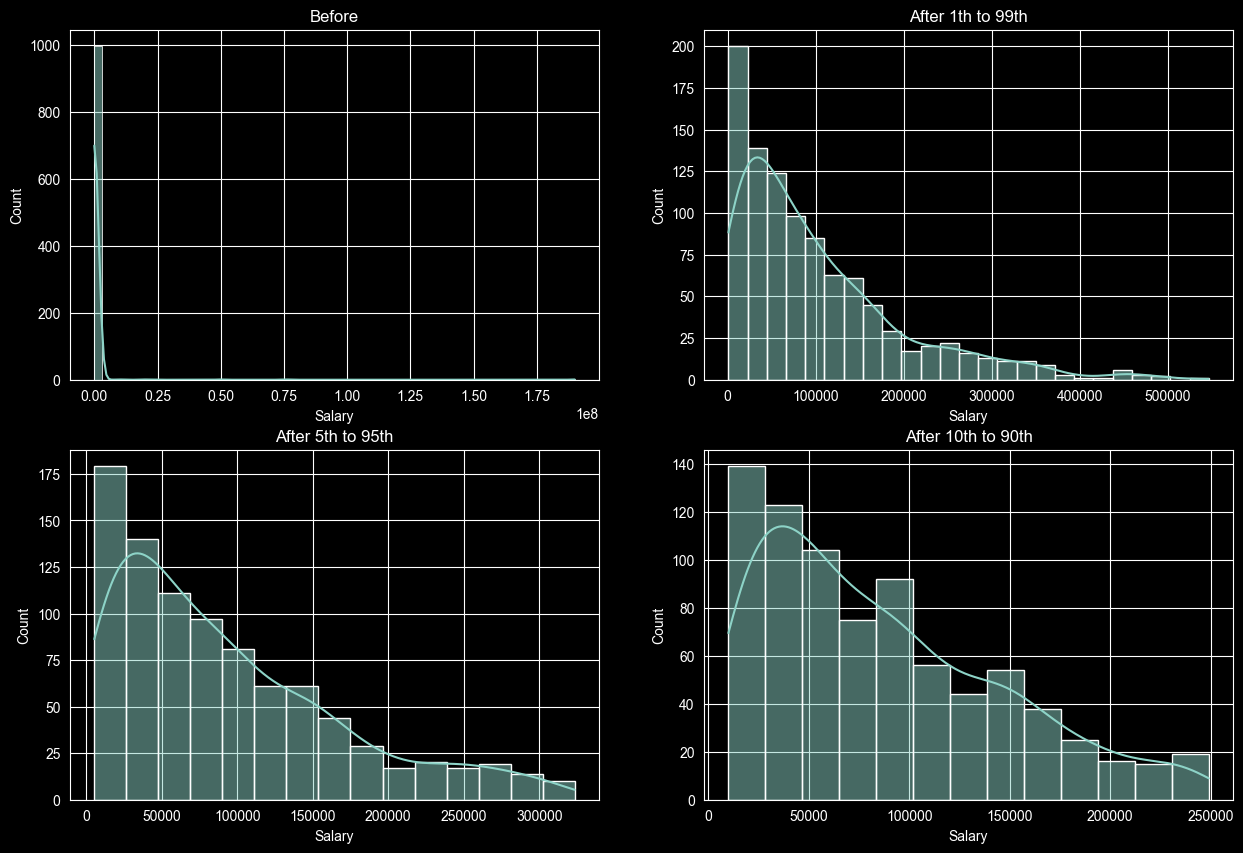

In [96]:
# Plot

figs, axes = plt.subplots(2,2,figsize=(15,10))

sns.histplot(data=df, x='Salary', ax=axes[0,0],kde=True)
axes[0,0].set_title('Before')

sns.histplot(data=df_clean_1_99, x='Salary', ax=axes[0,1],kde=True)
axes[0,1].set_title('After 1th to 99th')

sns.histplot(data=df_clean_5_95, x='Salary', ax=axes[1,0],kde=True)
axes[1,0].set_title('After 5th to 95th')

sns.histplot(data=df_clean_10_90, x='Salary', ax=axes[1,1],kde=True)
axes[1,1].set_title('After 10th to 90th')

plt.show()

#### Q3 - Winsorization Technique

In [97]:
# clip()

lower = df['Salary'].quantile(0.05)
upper = df['Salary'].quantile(0.95)

print(f"\n5th  percentile: {lower:.1f} min")
print(f"95th percentile: {upper:.1f} min")

df['Salary_win'] = df['Salary'].clip(lower=lower, upper=upper)


5th  percentile: 5361.9 min
95th percentile: 323420.1 min


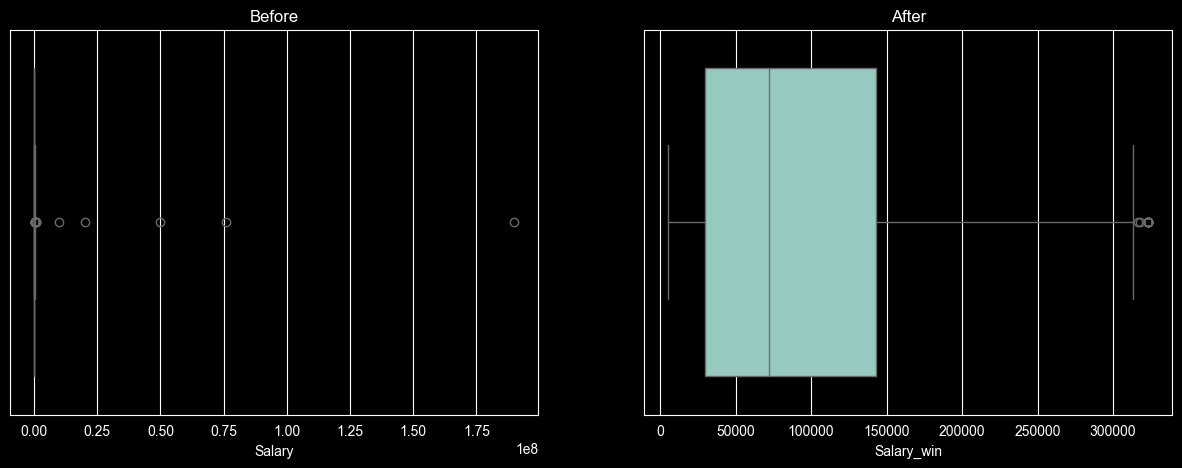

In [98]:
# plot

figs, axes = plt.subplots(1,2,figsize=(15,5))

sns.boxplot(data=df, x='Salary', ax=axes[0])
axes[0].set_title('Before')
sns.boxplot(data=df, x='Salary_win', ax=axes[1])
axes[1].set_title('After')

plt.show()



#### Q4 - Winsorization vs Z-score Removal

In [99]:
# winsorization

df['Salary_win'].head()


0    270853.225173
1      8220.783507
2    152398.096813
3    161815.368605
4      5361.903545
Name: Salary_win, dtype: float64

In [100]:
# Z-score

mean = df['Salary'].mean()
std = df['Salary'].std()

df['z_score'] = (df['Salary']-mean) / std

threshold = 3

df_z = df[df['z_score'].abs() <= threshold].copy()
df_z.drop(columns=['z_score'], inplace=True)
print(f'Cleaned Data: \n{df_z}')

Cleaned Data: 
            Salary     Salary_win
0    270853.225173  270853.225173
1      8220.783507    8220.783507
2    152398.096813  152398.096813
3    161815.368605  161815.368605
4      4981.101376    5361.903545
..             ...            ...
995   25188.710590   25188.710590
996   73285.668140   73285.668140
997  100641.516261  100641.516261
998  546205.879475  323420.063730
999   40792.209056   40792.209056

[997 rows x 2 columns]


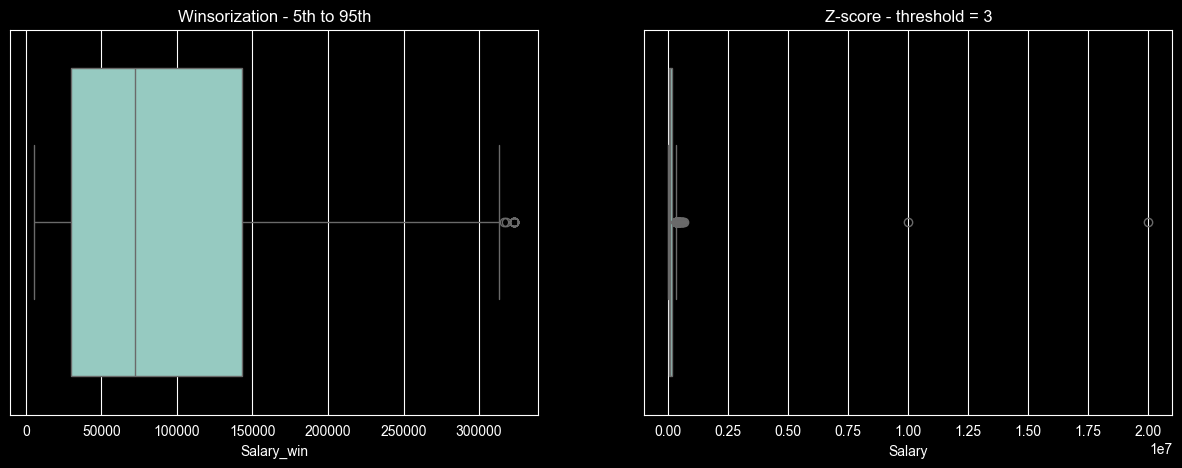

In [103]:
# plot

figs, axes = plt.subplots(1,2,figsize=(15,5))

sns.boxplot(data=df, x='Salary_win', ax=axes[0])
axes[0].set_title('Winsorization - 5th to 95th')
sns.boxplot(data=df_z, x='Salary', ax=axes[1])
axes[1].set_title('Z-score - threshold = 3')

plt.show()
